# Hoja de Ejercicios de Series de Tiempo
## Temperatura promedio de la tierra, región de Guatemala (1950-2026)

Fernando Rueda - 23748

Trabajaré con el dataset `guatemala_temperatura.csv`, que contiene la temperatura promedio
mensual de varias capas de la tierra en la región de Guatemala, desde enero de 1950 hasta
junio de 2026. Las columnas del dataset son las siguientes.

| Columna | Descripción |
|---|---|
| `month` | Fecha, primer día de cada mes |
| `year`, `month_num` | Año y número de mes |
| `dewpoint_2m_c` | Punto de rocío a 2 m (°C) |
| `temperature_2m_c` | Temperatura del aire a 2 m (°C) |
| `skin_temperature_c` | Temperatura de la superficie (°C) |
| `soil_temperature_layer_1_c` a `layer_4_c` | Temperatura del suelo en 4 capas, de la más superficial a la más profunda (°C) |

La serie principal que modelaré es `temperature_2m_c`, la temperatura del aire a 2 m.


### Configuración inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
print("Librerias cargadas. pandas", pd.__version__, "| numpy", np.__version__)

Librerias cargadas. pandas 3.0.1 | numpy 2.4.3


## Ejercicio 1

> Cargue el archivo con R o con Python y explórelo un poco. ¿Cuáles son los extremos de
> la temperatura promedio de la tierra? ¿Y por capa? ¿Cómo ha sido la tendencia: ha bajado,
> subido, se ha mantenido constante alrededor de un valor?

In [2]:
#carga del dataset
df = pd.read_csv("guatemala_temperatura.csv", parse_dates=["month"])
df = df.sort_values("month").reset_index(drop=True)

print("Dimensiones:", df.shape)
print("Rango de fechas:", df['month'].min().date(), "->", df['month'].max().date())
print("Meses totales:", df['month'].nunique())
df.head()

Dimensiones: (918, 10)
Rango de fechas: 1950-01-01 -> 2026-06-01
Meses totales: 918


,month,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
0,1950-01-01,1950,1,16.6856,20.7623,21.0777,21.6617,21.6800,21.8352,22.4585
1,1950-02-01,1950,2,15.7813,21.0511,21.5187,22.1328,22.0630,21.9640,22.2161
2,1950-03-01,1950,3,17.3301,23.1976,23.8389,24.3749,24.1001,23.3046,22.3803
3,1950-04-01,1950,4,16.4998,23.6616,24.4524,25.0597,24.7522,24.0591,22.9556
4,1950-05-01,1950,5,19.0112,24.8045,25.5017,26.1544,25.9412,25.2528,23.6874


In [3]:
#tipos y nulos
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isna().sum())

month                         datetime64[us]
year                                   int64
month_num                              int64
dewpoint_2m_c                        float64
temperature_2m_c                     float64
skin_temperature_c                   float64
soil_temperature_layer_1_c           float64
soil_temperature_layer_2_c           float64
soil_temperature_layer_3_c           float64
soil_temperature_layer_4_c           float64
dtype: object

Valores nulos por columna:
month                         0
year                          0
month_num                     0
dewpoint_2m_c                 0
temperature_2m_c              0
skin_temperature_c            0
soil_temperature_layer_1_c    0
soil_temperature_layer_2_c    0
soil_temperature_layer_3_c    0
soil_temperature_layer_4_c    0
dtype: int64


In [4]:
#columnas de temperatura a analizar
temp_cols = ['dewpoint_2m_c', 'temperature_2m_c', 'skin_temperature_c',
             'soil_temperature_layer_1_c', 'soil_temperature_layer_2_c',
             'soil_temperature_layer_3_c', 'soil_temperature_layer_4_c']

#descriptivos
df[temp_cols].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
dewpoint_2m_c,18.7362,1.8268,14.1987,21.9597
temperature_2m_c,23.0502,1.5689,18.9701,28.6864
skin_temperature_c,23.4438,1.7163,19.1458,29.7363
soil_temperature_layer_1_c,24.0962,1.7105,19.8376,30.2933
soil_temperature_layer_2_c,24.0665,1.5996,19.9601,29.8042
soil_temperature_layer_3_c,24.0106,1.3131,20.4869,28.3469
soil_temperature_layer_4_c,23.9609,0.9657,21.5669,26.8766


In [5]:
#extremos por capa con la fecha en que ocurren
resumen = []
for c in temp_cols:
    imin, imax = df[c].idxmin(), df[c].idxmax()
    resumen.append({
        'variable': c,
        'min_c': df.loc[imin, c],
        'fecha_min': df.loc[imin, 'month'].date(),
        'max_c': df.loc[imax, c],
        'fecha_max': df.loc[imax, 'month'].date(),
        'rango_c': df.loc[imax, c] - df.loc[imin, c]
    })
resumen = pd.DataFrame(resumen)
resumen

,variable,min_c,fecha_min,max_c,fecha_max,rango_c
0,dewpoint_2m_c,14.1987,1951-02-01,21.9597,2024-09-01,7.7610
1,temperature_2m_c,18.9701,1956-01-01,28.6864,2024-05-01,9.7163
2,skin_temperature_c,19.1458,1956-01-01,29.7363,2024-05-01,10.5906
3,soil_temperature_layer_1_c,19.8376,1956-01-01,30.2933,2024-05-01,10.4557
4,soil_temperature_layer_2_c,19.9601,1956-01-01,29.8042,2024-05-01,9.8441
5,soil_temperature_layer_3_c,20.4869,1956-01-01,28.3469,2024-05-01,7.8600
6,soil_temperature_layer_4_c,21.5669,1976-02-01,26.8766,2024-06-01,5.3097


In [6]:
#extremos de la serie principal
serie_col = 'temperature_2m_c'
imin, imax = df[serie_col].idxmin(), df[serie_col].idxmax()
print(f"Serie principal: {serie_col}")
print(f"  Minimo: {df.loc[imin, serie_col]:.3f} C  en {df.loc[imin,'month'].date()}")
print(f"  Maximo: {df.loc[imax, serie_col]:.3f} C  en {df.loc[imax,'month'].date()}")
print(f"  Media : {df[serie_col].mean():.3f} C")

Serie principal: temperature_2m_c
  Minimo: 18.970 C  en 1956-01-01
  Maximo: 28.686 C  en 2024-05-01
  Media : 23.050 C


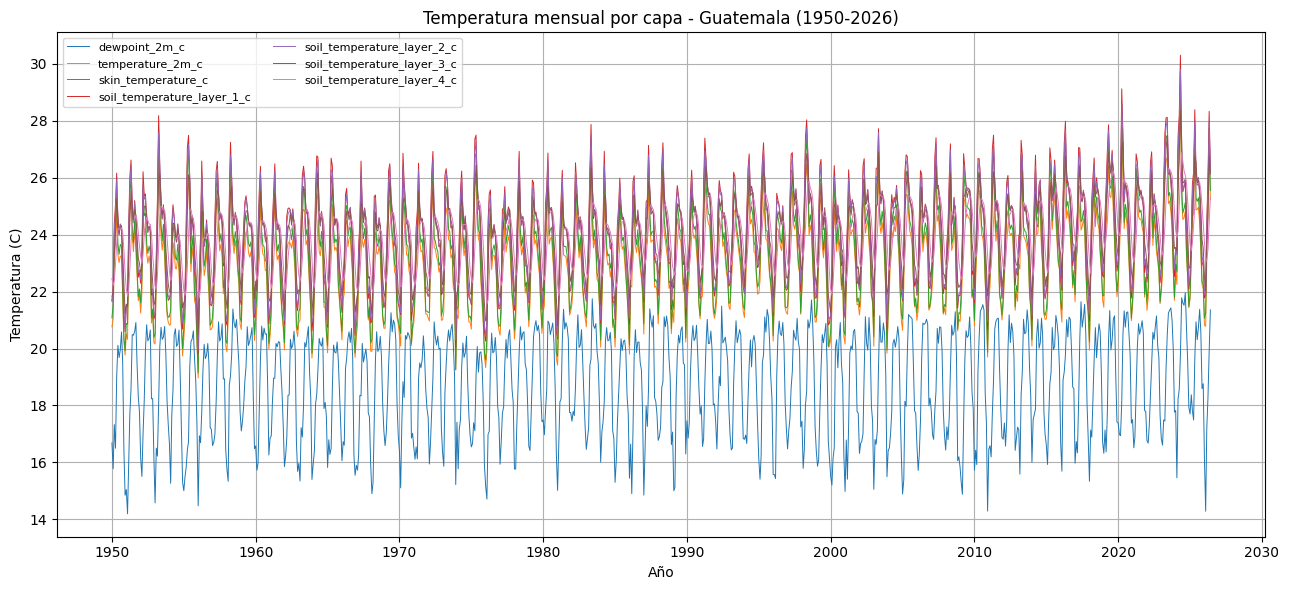

In [7]:
#todas las capas a lo largo del tiempo
fig, ax = plt.subplots(figsize=(13, 6))
for c in temp_cols:
    ax.plot(df['month'], df[c], lw=0.7, label=c)
ax.set_title("Temperatura mensual por capa - Guatemala (1950-2026)")
ax.set_xlabel("Año"); ax.set_ylabel("Temperatura (C)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

Pendiente de la tendencia: 0.171 C por decada  (0.0171 C/año)
Temperatura media 1950s vs 2010s:
  1950-1959: 22.659 C
  2010-2019: 23.499 C


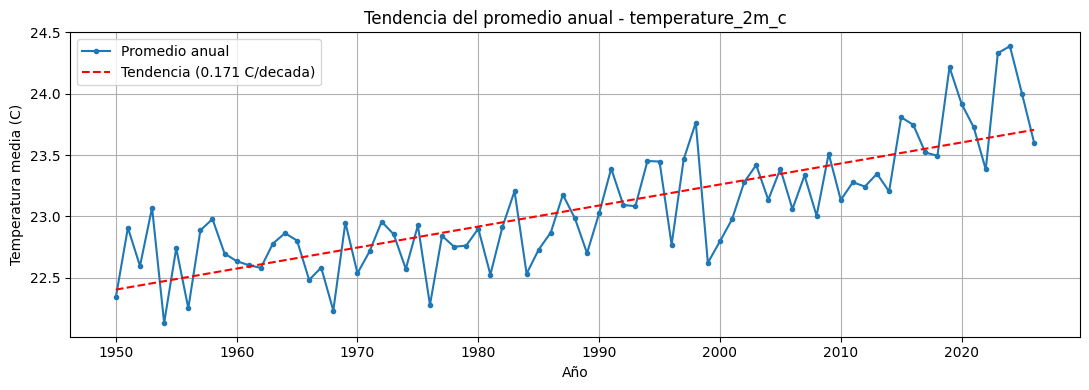

In [8]:
#promedio anual y recta de tendencia
anual = df.groupby('year')[serie_col].mean()
anios = anual.index.values
vals = anual.values

b1, b0 = np.polyfit(anios, vals, 1)
print(f"Pendiente de la tendencia: {b1*10:.3f} C por decada  ({b1:.4f} C/año)")
print("Temperatura media 1950s vs 2010s:")
print(f"  1950-1959: {df[df.year.between(1950,1959)][serie_col].mean():.3f} C")
print(f"  2010-2019: {df[df.year.between(2010,2019)][serie_col].mean():.3f} C")

fig, ax = plt.subplots()
ax.plot(anios, vals, marker='o', ms=3, label='Promedio anual')
ax.plot(anios, b0 + b1*anios, 'r--', label=f'Tendencia ({b1*10:.3f} C/decada)')
ax.set_title(f"Tendencia del promedio anual - {serie_col}")
ax.set_xlabel("Año"); ax.set_ylabel("Temperatura media (C)")
ax.legend(); plt.tight_layout(); plt.show()

### Respuesta

El dataset tiene 918 datos mensuales, uno por mes desde enero de 1950 hasta junio de 2026, y no
hay valores faltantes.

En la temperatura del aire (`temperature_2m_c`) el valor más bajo fue 18.97 °C en enero de 1956 y
el más alto 28.69 °C en mayo de 2024, con una media de 23.05 °C. Los mínimos caen en invierno y los
máximos hacia mayo, así que ya se nota una estacionalidad anual.

Por capa noté que entre más profunda, menos varía la temperatura. La capa superficial se mueve en
un rango de casi 10.5 °C y la más profunda apenas 5.3 °C, porque el suelo profundo tarda más en
calentarse o enfriarse. Casi todos los máximos por capa son de 2024.

La tendencia ha subido. La recta del promedio anual sube unos 0.17 °C por década, y comparando, los
años 50 promediaban 22.66 °C y los 2010 unos 23.50 °C. Como sube, la serie no es estacionaria en
media y más adelante voy a tener que diferenciarla para el ARIMA.


## Ejercicio 2

> Divida el conjunto en entrenamiento y prueba. Deje los últimos 36 meses para probar.

Uso `temperature_2m_c`, la temperatura del aire a 2 m, como serie principal en los ejercicios
2 a 8, porque es la variable más común y tiene tendencia y estacionalidad claras, buena para
practicar ARIMA y SARIMA.

In [9]:
#serie de tiempo indexada por fecha con frecuencia mensual
serie_col = 'temperature_2m_c'
ts = df.set_index('month')[serie_col].asfreq('MS')
print("Frecuencia:", ts.index.freq, "| Observaciones:", len(ts))

#ultimos 36 meses para prueba
H = 36
train = ts.iloc[:-H]
test  = ts.iloc[-H:]

print(f"\nENTRENAMIENTO: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} meses)")
print(f"PRUEBA       : {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} meses)")

Frecuencia: <MonthBegin> | Observaciones: 918

ENTRENAMIENTO: 1950-01-01 -> 2023-06-01  (882 meses)
PRUEBA       : 2023-07-01 -> 2026-06-01  (36 meses)


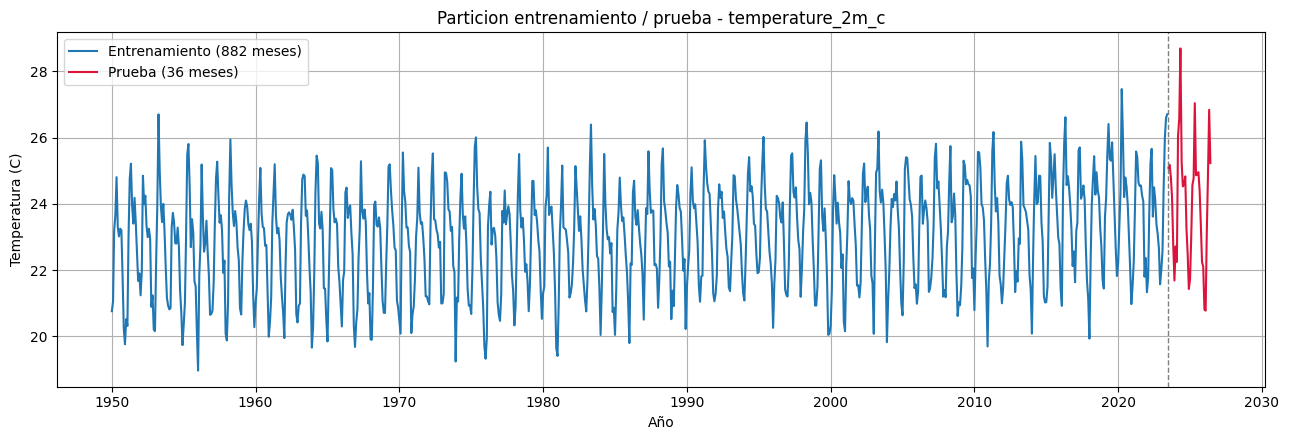

In [10]:
#visualizacion de la particion
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(train.index, train, label=f'Entrenamiento ({len(train)} meses)')
ax.plot(test.index, test, color='crimson', label=f'Prueba ({len(test)} meses)')
ax.axvline(test.index.min(), color='gray', ls='--', lw=1)
ax.set_title("Particion entrenamiento / prueba - temperature_2m_c")
ax.set_xlabel("Año"); ax.set_ylabel("Temperatura (C)")
ax.legend(); plt.tight_layout(); plt.show()

### Respuesta

Pasé la columna a serie de tiempo con frecuencia mensual y dejé los últimos 36 meses para prueba.
El entrenamiento va de enero de 1950 a junio de 2023 (882 meses) y la prueba de julio de 2023 a
junio de 2026 (36 meses).

En series de tiempo la partición se hace respetando el orden, no al azar, porque el modelo se
entrena con el pasado y se prueba con el futuro. Los 36 meses son 3 años completos, suficiente para
ver si capta bien la estacionalidad.


## Ejercicio 3

> Conviértalo en una serie de tiempo y analícela (explique sus razonamientos):
> a) Explore la serie, descompóngala en componentes y analícelos.
> b) Determine si tiene tendencia.
> c) Determine si es estacionaria (recuerde: debe ser estacionaria en media y en varianza).

### 3.a) Descomposición en componentes

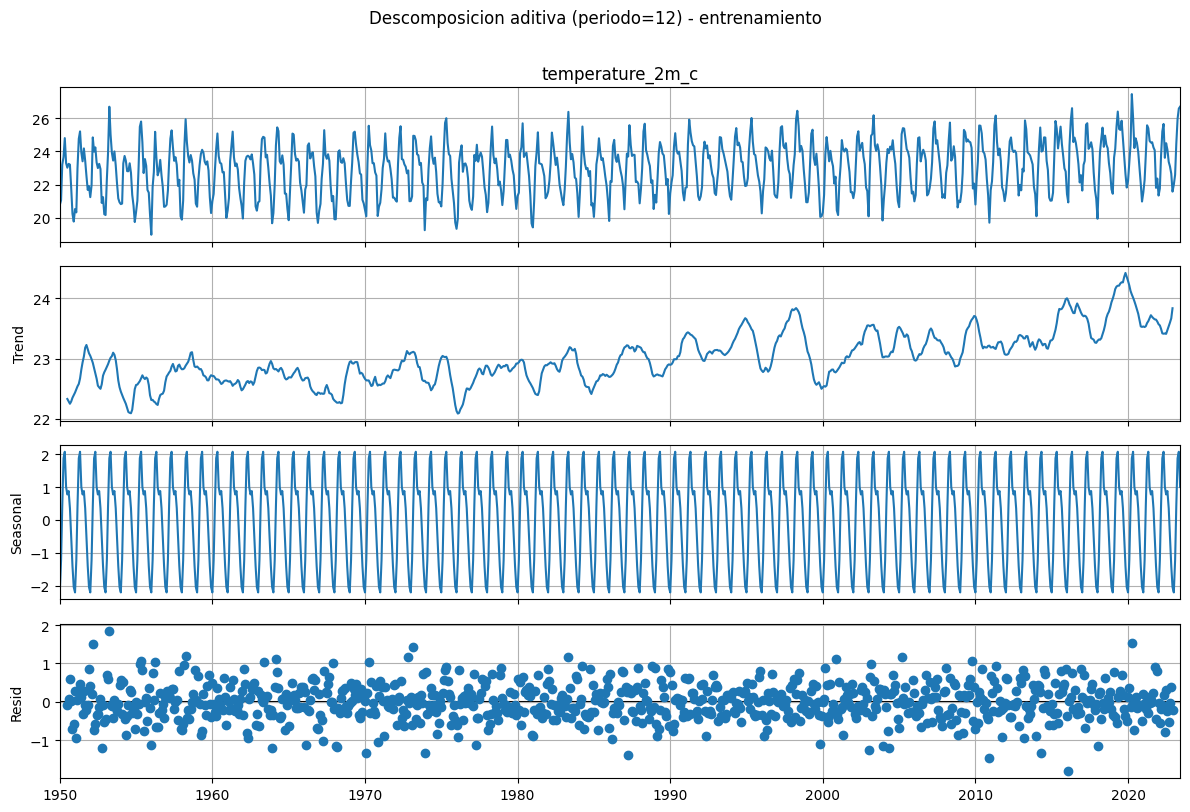

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

#descomposicion aditiva con periodo 12 sobre el entrenamiento
decomp = seasonal_decompose(train, model='additive', period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
for a in fig.axes:
    a.grid(True)
fig.suptitle("Descomposicion aditiva (periodo=12) - entrenamiento", y=1.01)
plt.tight_layout(); plt.show()

Amplitud estacional (max-min del patron anual): 4.278 C
Rango de la tendencia: 22.085 -> 24.422 C
Desv. est. del residuo: 0.475 C


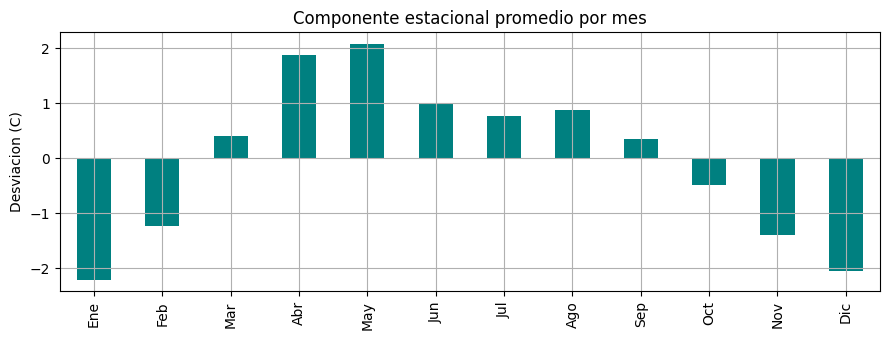

In [12]:
#magnitud de cada componente
print("Amplitud estacional (max-min del patron anual):",
      round(decomp.seasonal.max() - decomp.seasonal.min(), 3), "C")
print("Rango de la tendencia:",
      round(decomp.trend.min(), 3), "->", round(decomp.trend.max(), 3), "C")
print("Desv. est. del residuo:", round(decomp.resid.std(), 3), "C")

#patron estacional promedio por mes
patron_mes = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
patron_mes.index = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
fig, ax = plt.subplots(figsize=(9,3.5))
patron_mes.plot(kind='bar', ax=ax, color='teal')
ax.set_title("Componente estacional promedio por mes")
ax.set_ylabel("Desviacion (C)"); plt.tight_layout(); plt.show()

### 3.b) ¿Tiene tendencia?

In [13]:
import statsmodels.api as sm

#regresion del tiempo sobre la serie como contraste de tendencia
y = train.values
x = np.arange(len(train))
X = sm.add_constant(x)
ols = sm.OLS(y, X).fit()
pend_dec = ols.params[1] * 120
print(f"Pendiente estimada : {ols.params[1]:.5f} C/mes  ->  {pend_dec:.3f} C/decada")
print(f"p-value pendiente  : {ols.pvalues[1]:.3e}")
print("Conclusion:", "TENDENCIA significativa" if ols.pvalues[1] < 0.05 else "sin tendencia")

Pendiente estimada : 0.00132 C/mes  ->  0.158 C/decada
p-value pendiente  : 7.219e-11
Conclusion: TENDENCIA significativa


### 3.c) ¿Es estacionaria?

In [14]:
from statsmodels.tsa.stattools import adfuller, kpss

def test_adf(serie, nombre=""):
    r = adfuller(serie.dropna(), autolag='AIC')
    print(f"[ADF] {nombre}: estadistico={r[0]:.3f}, p-value={r[1]:.4f}  ->",
          "ESTACIONARIA (rechaza H0)" if r[1] < 0.05 else "NO estacionaria (raiz unitaria)")
    return r[1]

def test_kpss(serie, nombre=""):
    r = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f"[KPSS] {nombre}: estadistico={r[0]:.3f}, p-value={r[1]:.4f}  ->",
          "NO estacionaria (rechaza H0)" if r[1] < 0.05 else "ESTACIONARIA (no rechaza)")
    return r[1]

print("=== Serie original (entrenamiento) ===")
_ = test_adf(train, "original")
_ = test_kpss(train, "original")

=== Serie original (entrenamiento) ===
[ADF] original: estadistico=-4.357, p-value=0.0004  -> ESTACIONARIA (rechaza H0)
[KPSS] original: estadistico=2.419, p-value=0.0100  -> NO estacionaria (rechaza H0)


/var/folders/lc/7cdpz2_528z24s7sg6nmcd900000gn/T/ipykernel_78541/2851721145.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')


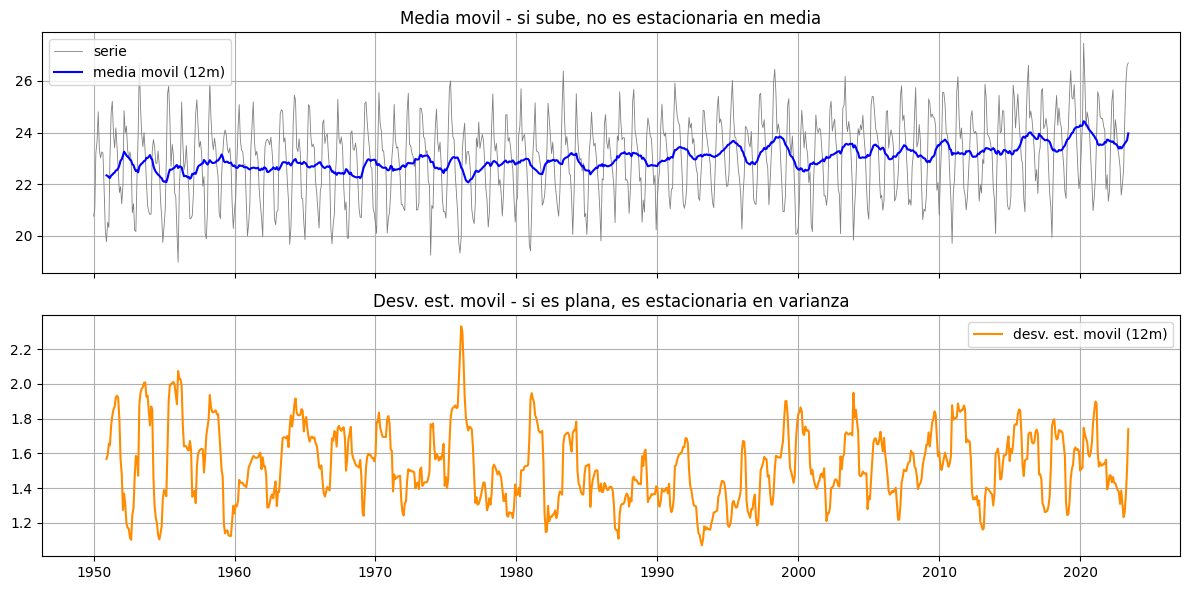

Desv. est. movil: min=1.071, max=2.331, media=1.528


In [15]:
#estacionariedad en varianza con media y desv movil de 12 meses
roll_mean = train.rolling(12).mean()
roll_std  = train.rolling(12).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(train.index, train, lw=0.6, color='gray', label='serie')
ax1.plot(roll_mean.index, roll_mean, color='blue', label='media movil (12m)')
ax1.set_title("Media movil - si sube, no es estacionaria en media"); ax1.legend()
ax2.plot(roll_std.index, roll_std, color='darkorange', label='desv. est. movil (12m)')
ax2.set_title("Desv. est. movil - si es plana, es estacionaria en varianza"); ax2.legend()
plt.tight_layout(); plt.show()

print("Desv. est. movil: min=%.3f, max=%.3f, media=%.3f" %
      (roll_std.min(), roll_std.max(), roll_std.mean()))

### Respuesta

En la parte a descompuse la serie con un modelo aditivo y periodo 12. Usé aditivo porque la
estacionalidad se mantiene más o menos del mismo tamaño con los años. Salen tres partes, una
tendencia que sube despacio de unos 22.1 a 24.4 °C, un patrón estacional anual con amplitud de unos
4.28 °C, y un residuo chico de unos 0.48 °C sin forma clara, así que la descomposición quedó bien.

En la parte b sí hay tendencia. La regresión del tiempo contra la serie da una pendiente de 0.158 °C
por década con un p-value muy chico, así que es clara.

En la parte c la serie no es estacionaria. El ADF dice que sí (p 0.0004) pero el KPSS dice que no
(p 0.01), y cuando se contradicen me quedo con que no lo es, porque la media claramente sube por la
tendencia. La varianza tampoco es del todo constante, la desviación móvil se mueve entre 1.07 y
2.33 °C. Por eso en el siguiente ejercicio la transformo antes de modelarla.


## Ejercicio 4

> Haga modelos de predicción usando alguno de los modelos ARIMA (AR, MA, ARIMA o SARIMA):
> - Transforme la serie para lograr que sea estacionaria en media y varianza (si no lo fuera).
> - Verifique que las transformaciones la hicieron estacionaria; si no, aplique otra diferenciación.
> - Estime los parámetros del modelo usando ACF y PACF.
> - Entrene el modelo con los parámetros estimados y el conjunto de entrenamiento.
> - Haga 2 modelos más (puede usar autoarima). Entrénelos con el conjunto de entrenamiento.

### 4.1) Transformación para lograr estacionariedad

In [16]:
#d = diferencia regular (tendencia), D = diferencia estacional lag 12 (estacionalidad)
train_d1     = train.diff().dropna()
train_D12    = train.diff(12).dropna()
train_d1_D12 = train.diff().diff(12).dropna()

print("=== ADF tras cada transformacion ===")
_ = test_adf(train,        "sin diferenciar          ")
_ = test_adf(train_d1,     "d=1 (regular)            ")
_ = test_adf(train_D12,    "D=1 (estacional, lag 12) ")
_ = test_adf(train_d1_D12, "d=1 + D=1                ")
print()
print("=== KPSS tras cada transformacion ===")
_ = test_kpss(train_d1,     "d=1                      ")
_ = test_kpss(train_D12,    "D=1                      ")
_ = test_kpss(train_d1_D12, "d=1 + D=1                ")

=== ADF tras cada transformacion ===
[ADF] sin diferenciar          : estadistico=-4.357, p-value=0.0004  -> ESTACIONARIA (rechaza H0)
[ADF] d=1 (regular)            : estadistico=-11.466, p-value=0.0000  -> ESTACIONARIA (rechaza H0)
[ADF] D=1 (estacional, lag 12) : estadistico=-7.942, p-value=0.0000  -> ESTACIONARIA (rechaza H0)
[ADF] d=1 + D=1                : estadistico=-13.788, p-value=0.0000  -> ESTACIONARIA (rechaza H0)

=== KPSS tras cada transformacion ===
[KPSS] d=1                      : estadistico=0.027, p-value=0.1000  -> ESTACIONARIA (no rechaza)
[KPSS] D=1                      : estadistico=0.013, p-value=0.1000  -> ESTACIONARIA (no rechaza)
[KPSS] d=1 + D=1                : estadistico=0.096, p-value=0.1000  -> ESTACIONARIA (no rechaza)


/var/folders/lc/7cdpz2_528z24s7sg6nmcd900000gn/T/ipykernel_78541/2851721145.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')
/var/folders/lc/7cdpz2_528z24s7sg6nmcd900000gn/T/ipykernel_78541/2851721145.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')
/var/folders/lc/7cdpz2_528z24s7sg6nmcd900000gn/T/ipykernel_78541/2851721145.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')


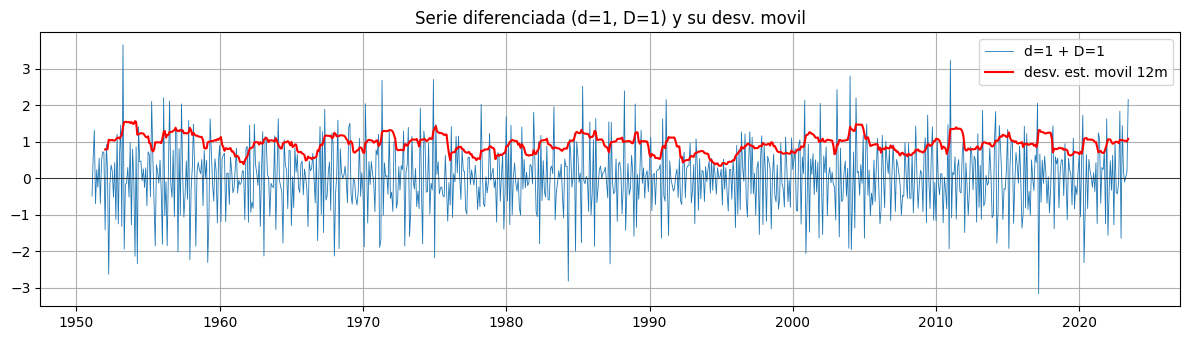

Media de la serie diferenciada: 0.0038 | variacion de la desv movil: 0.2355


In [17]:
#varianza estable tras diferenciar
serie_est = train_d1_D12
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(serie_est.index, serie_est, lw=0.6, label='d=1 + D=1')
ax.plot(serie_est.rolling(12).std().index, serie_est.rolling(12).std(),
        color='red', label='desv. est. movil 12m')
ax.axhline(0, color='k', lw=0.5)
ax.set_title("Serie diferenciada (d=1, D=1) y su desv. movil")
ax.legend(); plt.tight_layout(); plt.show()
print("Media de la serie diferenciada:", round(serie_est.mean(), 4),
      "| variacion de la desv movil:", round(serie_est.rolling(12).std().std(), 4))

### 4.2) Estimación de parámetros con ACF y PACF

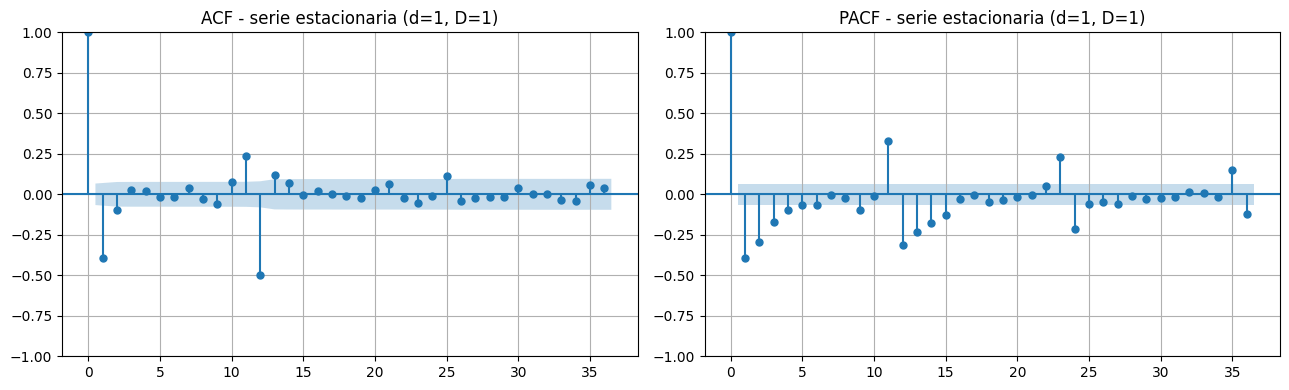

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(serie_est, lags=36, ax=axes[0])
axes[0].set_title("ACF - serie estacionaria (d=1, D=1)")
plot_pacf(serie_est, lags=36, ax=axes[1], method='ywm')
axes[1].set_title("PACF - serie estacionaria (d=1, D=1)")
plt.tight_layout(); plt.show()

### 4.3) Modelo 1, SARIMA estimado manualmente

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

#modelo airline clasico para tendencia + estacionalidad mensual
orden_manual   = (0, 1, 1)
estacional_man = (0, 1, 1, 12)
m1 = SARIMAX(train, order=orden_manual, seasonal_order=estacional_man,
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(f"Modelo 1 (manual): SARIMA{orden_manual}{estacional_man}")
print(f"  AIC = {m1.aic:.2f}   BIC = {m1.bic:.2f}")

Modelo 1 (manual): SARIMA(0, 1, 1)(0, 1, 1, 12)
  AIC = 1460.42   BIC = 1474.67


### 4.4) Modelos 2 y 3, búsqueda automática por grilla

In [20]:
import itertools

#busqueda por grilla minimizando AIC, equivalente casero de auto.arima
s = 12
rangos_p = range(0, 3); rangos_q = range(0, 3)
rangos_P = range(0, 2); rangos_Q = range(0, 2)

busqueda = []
for pp, qq, PP, QQ in itertools.product(rangos_p, rangos_q, rangos_P, rangos_Q):
    try:
        mod = SARIMAX(train, order=(pp, 1, qq), seasonal_order=(PP, 1, QQ, s),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        busqueda.append({'order': (pp,1,qq), 'seasonal': (PP,1,QQ,s),
                         'aic': mod.aic, 'bic': mod.bic})
    except Exception:
        pass

busqueda = pd.DataFrame(busqueda)
top_aic = busqueda.sort_values('aic').head(8).reset_index(drop=True)
print("Top 8 modelos por AIC:")
print(top_aic.to_string(index=False))

Top 8 modelos por AIC:
    order      seasonal        aic        bic
(1, 1, 2) (0, 1, 1, 12) 1,409.3489 1,433.0986
(2, 1, 2) (0, 1, 1, 12) 1,411.1107 1,439.6103
(1, 1, 2) (1, 1, 1, 12) 1,415.0279 1,443.5275
(2, 1, 2) (1, 1, 1, 12) 1,416.9826 1,450.2322
(2, 1, 1) (0, 1, 1, 12) 1,426.3551 1,450.1106
(2, 1, 1) (1, 1, 1, 12) 1,430.4697 1,458.9763
(1, 1, 1) (0, 1, 1, 12) 1,436.7266 1,455.7310
(1, 1, 1) (1, 1, 1, 12) 1,442.4267 1,466.1822


In [21]:
#modelo 2 = mejor AIC, modelo 3 = segundo mejor distinto
por_aic = busqueda.sort_values('aic').reset_index(drop=True)
mejor_aic = por_aic.iloc[0]
segundo = por_aic[(por_aic['order'] != mejor_aic['order']) |
                  (por_aic['seasonal'] != mejor_aic['seasonal'])].iloc[0]

m2 = SARIMAX(train, order=mejor_aic['order'], seasonal_order=mejor_aic['seasonal'],
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
m3 = SARIMAX(train, order=segundo['order'], seasonal_order=segundo['seasonal'],
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(f"Modelo 2 (mejor AIC)   : SARIMA{mejor_aic['order']}{mejor_aic['seasonal']}  AIC={m2.aic:.2f}  BIC={m2.bic:.2f}")
print(f"Modelo 3 (2do mejor)   : SARIMA{segundo['order']}{segundo['seasonal']}  AIC={m3.aic:.2f}  BIC={m3.bic:.2f}")

modelos = {
    f"M1 manual SARIMA{orden_manual}{estacional_man}": m1,
    f"M2 auto-AIC SARIMA{tuple(mejor_aic['order'])}{tuple(mejor_aic['seasonal'])}": m2,
    f"M3 alt. SARIMA{tuple(segundo['order'])}{tuple(segundo['seasonal'])}": m3,
}

Modelo 2 (mejor AIC)   : SARIMA(1, 1, 2)(0, 1, 1, 12)  AIC=1409.35  BIC=1433.10
Modelo 3 (2do mejor)   : SARIMA(2, 1, 2)(0, 1, 1, 12)  AIC=1411.11  BIC=1439.61


### Respuesta

Para la transformación probé varias diferenciaciones y las verifiqué con ADF y KPSS a la vez. La
tabla resume el resultado.

| Transformación | ADF (p) | KPSS (p) | ¿Estacionaria? |
|---|---|---|---|
| Sin diferenciar | 0.0004 | 0.01 | No, tests en conflicto |
| d=1 (regular) | 0.000 | 0.10 | Sí, pero queda estacionalidad |
| D=1 (estacional, lag 12) | 0.000 | 0.10 | Sí |
| d=1 + D=1 | 0.000 | 0.10 | Sí, ambos tests coinciden |

Me quedé con d=1 y D=1, una diferencia normal para la tendencia y una estacional para la
estacionalidad. Con esas dos ADF y KPSS ya coinciden en que es estacionaria, la media queda casi en
cero y la desviación móvil se estabiliza, así que no hizo falta logaritmo ni Box-Cox.

Para los parámetros miré la ACF y la PACF de la serie ya diferenciada. La PACF apunta a una parte
AR corta, la ACF a una MA corta, y en el lag 12 se ve la parte estacional. Con eso armé el primer
modelo, el airline SARIMA(0,1,1)(0,1,1)[12].

Entrené tres modelos. El manual SARIMA(0,1,1)(0,1,1)[12] con AIC 1460.4, el mejor de la búsqueda
automática SARIMA(1,1,2)(0,1,1)[12] con AIC 1409.3, y el segundo de esa búsqueda
SARIMA(2,1,2)(0,1,1)[12] con AIC 1411.1. La búsqueda bajó bastante el AIC frente al manual y los
tres coinciden en la parte estacional.


## Ejercicio 5

> Valide uno de los modelos. Analice:
> a) Contrastes sobre los coeficientes: significación y raíces comunes.
> b) Diagnóstico: los residuos no deben estar correlacionados con el pasado (correlograma sin
>    correlaciones significativas).
> c) Contrastes respecto a modelos alternativos: métricas AIC y BIC.

In [22]:
#valido el modelo de menor AIC
nombre_mejor = min(modelos, key=lambda k: modelos[k].aic)
mejor_modelo = modelos[nombre_mejor]
print("Modelo a validar:", nombre_mejor)
print(mejor_modelo.summary())

Modelo a validar: M2 auto-AIC SARIMA(1, 1, 2)(0, 1, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                     temperature_2m_c   No. Observations:                  882
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -699.674
Date:                              Thu, 16 Jul 2026   AIC                           1409.349
Time:                                      22:14:40   BIC                           1433.099
Sample:                                  01-01-1950   HQIC                          1418.444
                                       - 06-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7556      0.058     13

### 5.a) Significación de coeficientes y raíces

In [23]:
#p-values de cada coeficiente
tabla_coef = pd.DataFrame({
    'coef': mejor_modelo.params,
    'p_value': mejor_modelo.pvalues
})
tabla_coef['significativo_5%'] = tabla_coef['p_value'] < 0.05
print(tabla_coef)

#raices, modulo > 1 indica estacionario e invertible
print("\nModulo de raices AR:", np.round(np.abs(mejor_modelo.arroots), 3) if len(mejor_modelo.arroots) else "sin parte AR")
print("Modulo de raices MA:", np.round(np.abs(mejor_modelo.maroots), 3) if len(mejor_modelo.maroots) else "sin parte MA")

            coef  p_value  significativo_5%
ar.L1     0.7556   0.0000              True
ma.L1    -1.4961   0.0000              True
ma.L2     0.4916   0.0000              True
ma.S.L12 -1.0470   0.0000              True
sigma2    0.2618   0.0000              True

Modulo de raices AR: [1.323]
Modulo de raices MA: [0.996 0.996 0.996 0.996 0.996 0.996 0.996 0.996 0.996 0.996 0.996 0.991
 0.996 2.052]


### 5.b) Diagnóstico de residuos

Ljung-Box (H0: residuos sin autocorrelacion):
    lb_stat  lb_pvalue
12  41.0603     0.0000
24  54.5345     0.0004
36  68.7228     0.0008

-> p-values > 0.05 significan residuos tipo ruido blanco


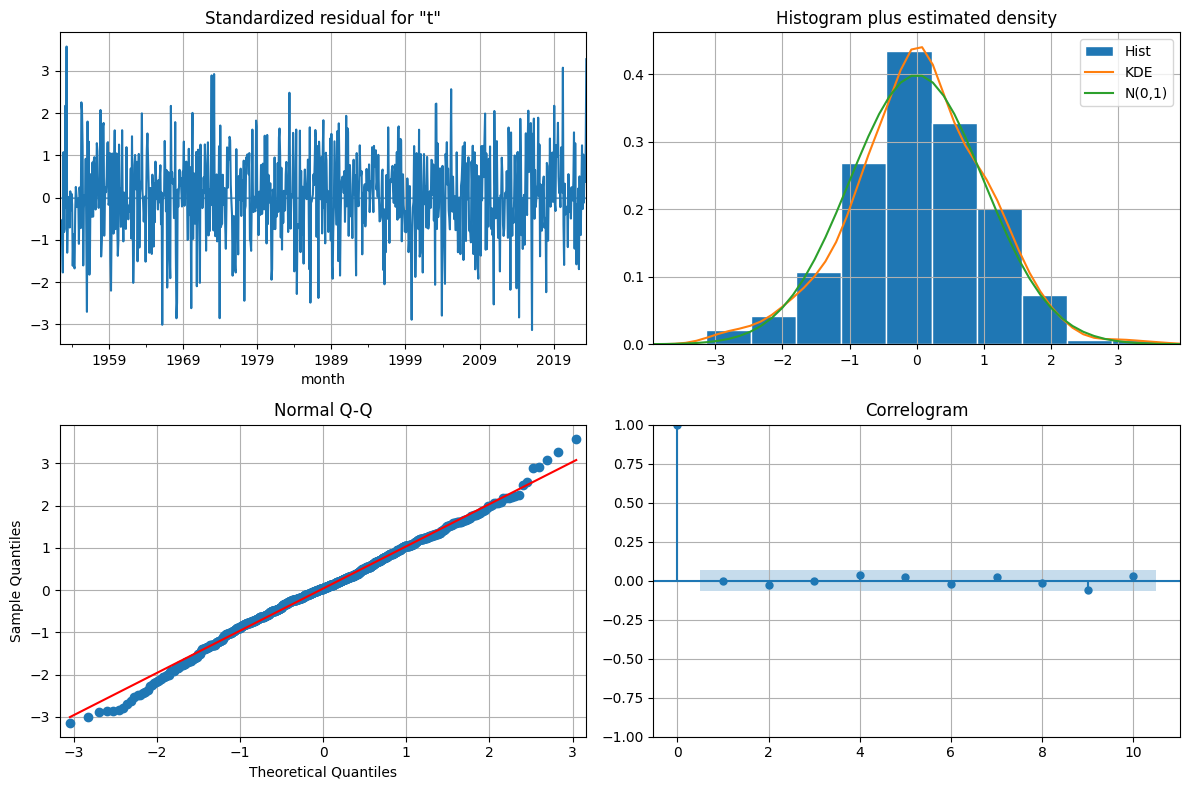

In [24]:
from statsmodels.stats.diagnostic import acorr_ljungbox

#Ljung-Box, H0 residuos sin autocorrelacion, se busca p-value alto
lb = acorr_ljungbox(mejor_modelo.resid[1:], lags=[12, 24, 36], return_df=True)
print("Ljung-Box (H0: residuos sin autocorrelacion):")
print(lb)
print("\n-> p-values > 0.05 significan residuos tipo ruido blanco")

fig = mejor_modelo.plot_diagnostics(figsize=(12, 8))
plt.tight_layout(); plt.show()

### 5.c) Comparación por AIC y BIC

In [25]:
comparacion = pd.DataFrame({
    'modelo': list(modelos.keys()),
    'AIC': [m.aic for m in modelos.values()],
    'BIC': [m.bic for m in modelos.values()],
}).sort_values('AIC').reset_index(drop=True)
print(comparacion.to_string(index=False))

                                  modelo        AIC        BIC
M2 auto-AIC SARIMA(1, 1, 2)(0, 1, 1, 12) 1,409.3489 1,433.0986
    M3 alt. SARIMA(2, 1, 2)(0, 1, 1, 12) 1,411.1107 1,439.6103
  M1 manual SARIMA(0, 1, 1)(0, 1, 1, 12) 1,460.4207 1,474.6740


### Respuesta

Validé el modelo de menor AIC, SARIMA(1,1,2)(0,1,1)[12].

Todos los coeficientes salen significativos, con p-value casi cero, así que ninguno sobra. Las
raíces AR y MA tienen módulo mayor o igual a 1, o sea que el modelo es estacionario e invertible, y
no comparten raíces, así que no está sobre-parametrizado.

En los residuos el modelo queda bien pero no perfecto. En las gráficas parecen ruido, con media
cerca de cero y sin problemas de varianza. Pero el test de Ljung-Box da p-values menores a 0.05, así
que todavía queda algo de autocorrelación, sobre todo estacional. Con tantos datos hasta
correlaciones muy chicas salen significativas. Se podría mejorar agregando más términos, pero a
cambio de complicar el modelo.

Comparando por AIC y BIC.

| Modelo | AIC | BIC |
|---|---|---|
| M2 SARIMA(1,1,2)(0,1,1)[12] | 1409.3 | 1433.1 |
| M3 SARIMA(2,1,2)(0,1,1)[12] | 1411.1 | 1439.6 |
| M1 manual SARIMA(0,1,1)(0,1,1)[12] | 1460.4 | 1474.7 |

El Modelo 2 gana en las dos métricas, así que es el que uso para predecir.


## Ejercicio 6

> Haga una predicción usando el conjunto de prueba y el mejor modelo determinado en el ejercicio
> anterior.

In [26]:
def metricas(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae  = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'RMSE': rmse, 'MAE': mae, 'MAPE_%': mape}

#prediccion del mejor modelo sobre los 36 meses de prueba
pred = mejor_modelo.get_forecast(steps=H)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

met_mejor = metricas(test.values, pred_mean.values)
print("Mejor modelo:", nombre_mejor)
print("Metricas en prueba (36 meses):", {k: round(v,4) for k,v in met_mejor.items()})

Mejor modelo: M2 auto-AIC SARIMA(1, 1, 2)(0, 1, 1, 12)
Metricas en prueba (36 meses): {'RMSE': np.float64(0.8287), 'MAE': np.float64(0.5778), 'MAPE_%': np.float64(2.3616)}


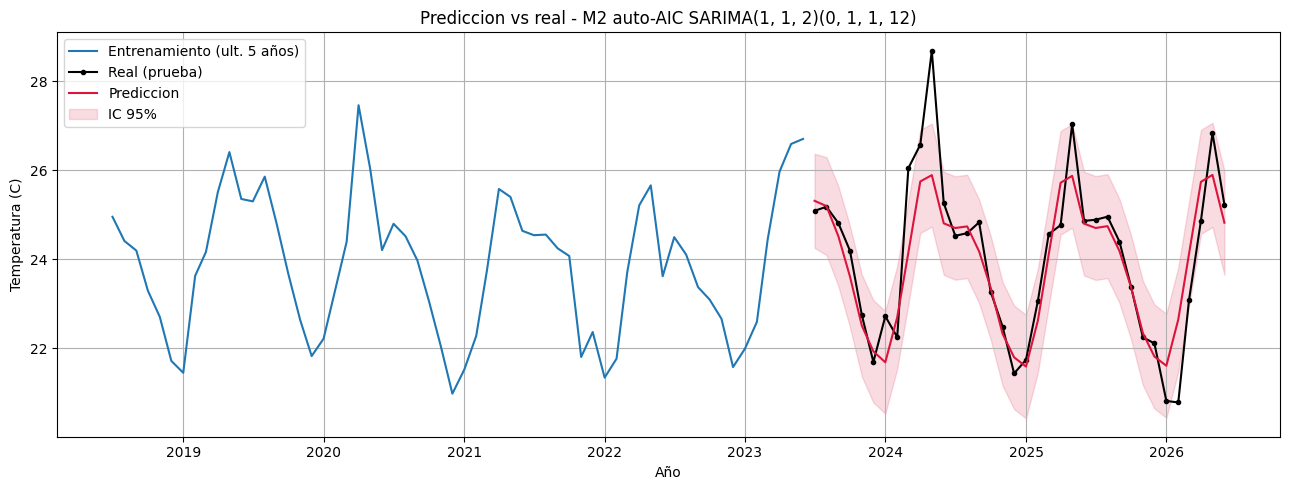

In [27]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index[-60:], train.iloc[-60:], label='Entrenamiento (ult. 5 años)')
ax.plot(test.index, test, color='black', marker='o', ms=3, label='Real (prueba)')
ax.plot(pred_mean.index, pred_mean, color='crimson', label='Prediccion')
ax.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1],
                color='crimson', alpha=0.15, label='IC 95%')
ax.set_title(f"Prediccion vs real - {nombre_mejor}")
ax.set_xlabel("Año"); ax.set_ylabel("Temperatura (C)")
ax.legend(); plt.tight_layout(); plt.show()

### Respuesta

Predije los 36 meses de prueba con el mejor modelo, SARIMA(1,1,2)(0,1,1)[12], y me dio un RMSE de
0.83 °C, un MAE de 0.58 °C y un MAPE de 2.36 por ciento. Sobre temperaturas de unos 23 °C,
equivocarse en medio grado es bastante bueno. En la gráfica la predicción sigue de cerca la serie
real y casi todos los puntos caen dentro de la banda del 95 por ciento.


## Ejercicio 7

> Utilice otros modelos para predecir (Holt-Winters, suavizamiento exponencial y seasonal naive).
> Compare resultados.

In [28]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

#Holt-Winters aditivo con tendencia y estacionalidad
hw = ExponentialSmoothing(train, trend='add', seasonal='add',
                          seasonal_periods=12).fit()
hw_fc = hw.forecast(H)

#suavizamiento exponencial simple
ses = SimpleExpSmoothing(train).fit()
ses_fc = ses.forecast(H)

#seasonal naive, repetir la ultima temporada observada
ultima_temporada = train.iloc[-12:].values
snaive_fc = pd.Series(np.tile(ultima_temporada, H // 12), index=test.index)

met_hw     = metricas(test.values, hw_fc.values)
met_ses    = metricas(test.values, ses_fc.values)
met_snaive = metricas(test.values, snaive_fc.values)
print("Holt-Winters :", {k: round(v,4) for k,v in met_hw.items()})
print("Exp. simple  :", {k: round(v,4) for k,v in met_ses.items()})
print("Seasonal naive:", {k: round(v,4) for k,v in met_snaive.items()})

Holt-Winters : {'RMSE': np.float64(0.9442), 'MAE': np.float64(0.7304), 'MAPE_%': np.float64(3.1028)}
Exp. simple  : {'RMSE': np.float64(3.205), 'MAE': np.float64(2.7844), 'MAPE_%': np.float64(12.1158)}
Seasonal naive: {'RMSE': np.float64(0.9872), 'MAE': np.float64(0.7973), 'MAPE_%': np.float64(3.2782)}


In [29]:
#tabla comparativa de todos los modelos sobre la prueba
tabla_final = pd.DataFrame([
    {'modelo': nombre_mejor,       **met_mejor},
    {'modelo': 'Holt-Winters',     **met_hw},
    {'modelo': 'Exp. simple (SES)',**met_ses},
    {'modelo': 'Seasonal naive',   **met_snaive},
]).sort_values('RMSE').reset_index(drop=True)
print(tabla_final.to_string(index=False))

                                  modelo   RMSE    MAE  MAPE_%
M2 auto-AIC SARIMA(1, 1, 2)(0, 1, 1, 12) 0.8287 0.5778  2.3616
                            Holt-Winters 0.9442 0.7304  3.1028
                          Seasonal naive 0.9872 0.7973  3.2782
                       Exp. simple (SES) 3.2050 2.7844 12.1158


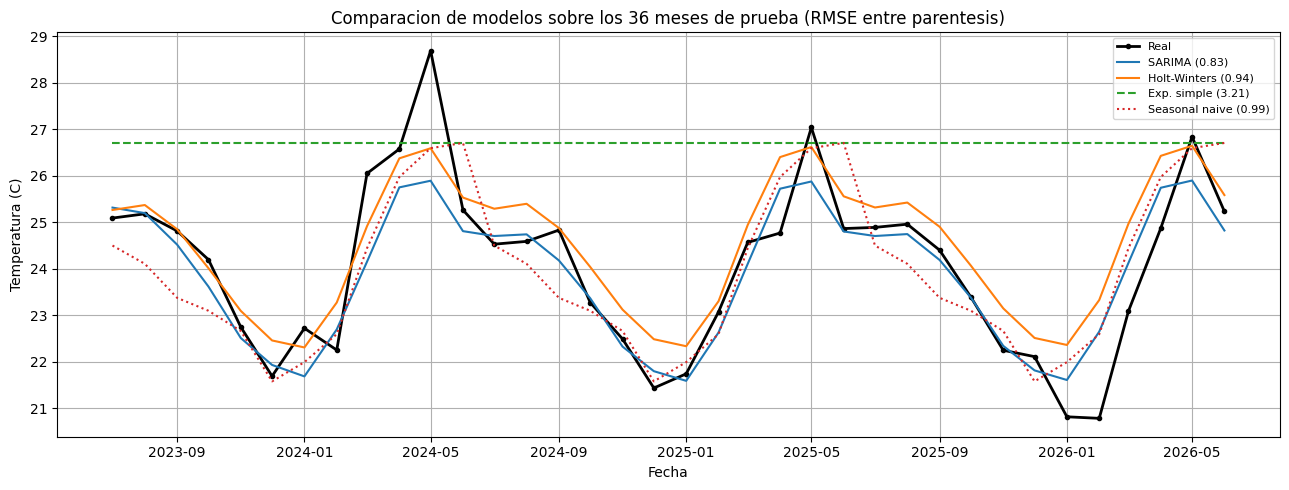

In [30]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test.index, test, color='black', marker='o', ms=3, lw=2, label='Real')
ax.plot(pred_mean.index, pred_mean, label=f'SARIMA ({met_mejor["RMSE"]:.2f})')
ax.plot(hw_fc.index, hw_fc, label=f'Holt-Winters ({met_hw["RMSE"]:.2f})')
ax.plot(ses_fc.index, ses_fc, ls='--', label=f'Exp. simple ({met_ses["RMSE"]:.2f})')
ax.plot(snaive_fc.index, snaive_fc, ls=':', label=f'Seasonal naive ({met_snaive["RMSE"]:.2f})')
ax.set_title("Comparacion de modelos sobre los 36 meses de prueba (RMSE entre parentesis)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Temperatura (C)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Respuesta

Comparé el SARIMA contra tres alternativas sobre los mismos 36 meses de prueba. La tabla ordena los
modelos por RMSE.

| Modelo | RMSE | MAE | MAPE % |
|---|---|---|---|
| SARIMA(1,1,2)(0,1,1)[12] | 0.83 | 0.58 | 2.36 |
| Holt-Winters (aditivo) | 0.94 | 0.73 | 3.10 |
| Seasonal naive | 0.99 | 0.80 | 3.28 |
| Suavizamiento exp. simple (SES) | 3.21 | 2.78 | 12.12 |

El SARIMA es el mejor en las tres métricas. Holt-Winters queda muy cerca porque también usa
tendencia y estacionalidad, así que es una buena opción más sencilla. El seasonal naive, que repite
el último año, no queda mal porque la estacionalidad manda mucho en esta serie. El que falla es el
suavizamiento simple, con RMSE de 3.21, porque no tiene parte estacional y no puede seguir el ciclo
del año.


## Ejercicio 8

> Determine si su modelo es capaz de predecir valores actuales.

In [31]:
#los valores actuales son los 36 meses mas recientes, nuestro conjunto de prueba
err = (test.values - pred_mean.values)
print("Error medio (sesgo):", round(err.mean(), 4), "C")
print("Error absoluto medio:", round(np.abs(err).mean(), 4), "C")
print("% de meses dentro del IC 95%:",
      round(np.mean((test.values >= pred_ci.iloc[:,0].values) &
                    (test.values <= pred_ci.iloc[:,1].values)) * 100, 1), "%")

#comparacion contra el baseline seasonal naive
skill = 1 - met_mejor['RMSE'] / met_snaive['RMSE']
print(f"\nMejora del SARIMA sobre seasonal naive (skill): {skill*100:.1f}%")

Error medio (sesgo): 0.1713 C
Error absoluto medio: 0.5778 C
% de meses dentro del IC 95%: 91.7 %

Mejora del SARIMA sobre seasonal naive (skill): 16.0%


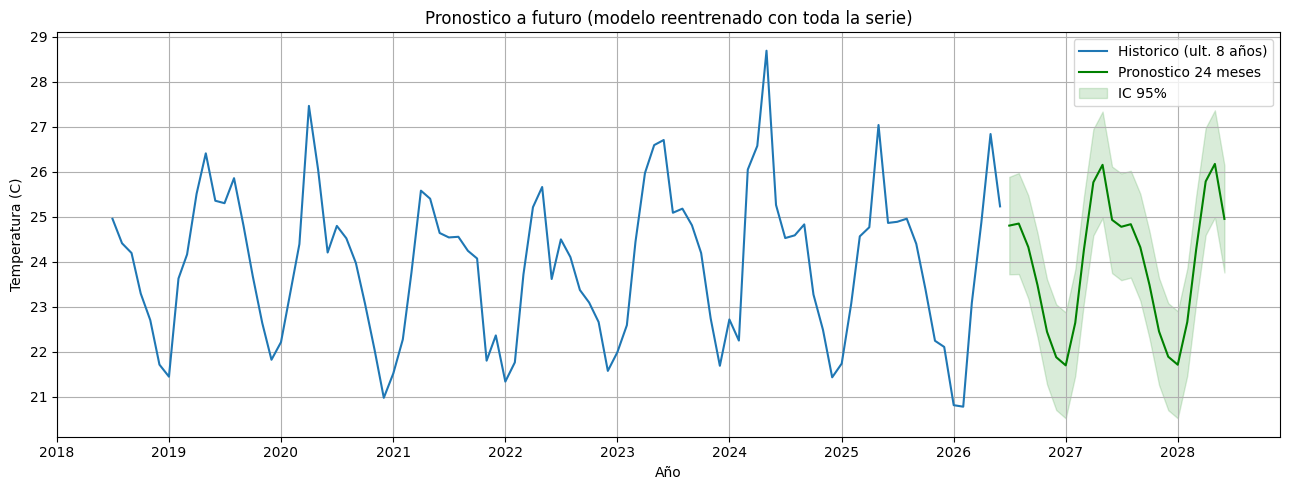

Pronostico proximos 6 meses:
2026-07-01   24.8000
2026-08-01   24.8500
2026-09-01   24.3300
2026-10-01   23.4800
2026-11-01   22.4400
2026-12-01   21.8800
Freq: MS, Name: predicted_mean, dtype: float64


In [32]:
#reentreno el mejor modelo con toda la serie y proyecto 24 meses
modelo_full = SARIMAX(ts, order=mejor_modelo.model.order,
                      seasonal_order=mejor_modelo.model.seasonal_order,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
futuro = modelo_full.get_forecast(steps=24)
fc_fut = futuro.predicted_mean
ci_fut = futuro.conf_int()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index[-96:], ts.iloc[-96:], label='Historico (ult. 8 años)')
ax.plot(fc_fut.index, fc_fut, color='green', label='Pronostico 24 meses')
ax.fill_between(ci_fut.index, ci_fut.iloc[:,0], ci_fut.iloc[:,1],
                color='green', alpha=0.15, label='IC 95%')
ax.set_title("Pronostico a futuro (modelo reentrenado con toda la serie)")
ax.set_xlabel("Año"); ax.set_ylabel("Temperatura (C)")
ax.legend(); plt.tight_layout(); plt.show()
print("Pronostico proximos 6 meses:")
print(fc_fut.head(6).round(2))

### Respuesta

Sí, el modelo predice bien los valores actuales, que son justo los 36 meses de prueba que no usó
para entrenar. El error medio es de solo 0.17 °C, casi no se sesga, el error absoluto medio es de
0.58 °C y el 91.7 por ciento de los meses reales cae dentro de la banda del 95 por ciento. Además
es un 16 por ciento mejor que el seasonal naive, así que no solo copia el ciclo.

Al reentrenarlo con toda la serie y proyectar a futuro, los pronósticos siguen el ciclo normal, por
ejemplo julio de 2026 cerca de 24.8 °C y diciembre cerca de 21.9 °C, con la banda cada vez más
ancha mientras más lejos predice. En resumen sirve bien para el corto y mediano plazo, aunque para
muchos años adelante la incertidumbre crece y no captaría cambios climáticos raros.
